In [23]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import ast

df = pd.read_csv("data/recipes_cleaned_labeled.csv")

In [24]:
def _parse_ingredient_list(value):
    """
    Safely parse a string representing a Python list into an actual list.
    """
    try:
        parsed = ast.literal_eval(value) if isinstance(value, str) else value
        return parsed if isinstance(parsed, list) else []
    except Exception:
        return []
        
df["ingredients_cleaned"] = df.ingredients_cleaned.map(_parse_ingredient_list)

In [25]:
df_healthy = df[df['Healthy']=='yes']
df_unhealthy = df[df['Healthy']=='no']

In [26]:
df.head()

,recipe_title,category,subcategory,description,ingredients,directions,num_ingredients,num_steps,Healthy,Healthy_confidence,Healthy_reason,Healthy_raw_response,ingredients_list,ingredients_cleaned
0,Air Fryer Potato Slices with Dipping Sauce,Air Fryer Recipes,Air Fryer Recipes,"These air fryer potato slices, served with a b...","[""3/4 cup ketchup"", ""1/2 cup beer"", ""1 tablesp...","[""Combine ketchup, beer, Worcestershire sauce,...",9,5,no,0.8,high in sodium and carbs,"{""healthy"":""no"",""confidence"":0.8,""reason"":""hig...","['ketchup', 'beer', 'worcestershire sauce', 'o...","[ketchup, beer, worcestershire sauce, onion po..."
1,Gochujang Pork Belly Bites,Air Fryer Recipes,Air Fryer Recipes,These gochujang pork belly bites are sweet and...,"[""1 pound pork belly"", ""1/4 cup gochujang"", ""2...","[""Preheat an air fryer to 400 degrees F (200 d...",5,4,no,0.8,high in fat and sugar,"{""healthy"":""no"",""confidence"":0.8,""reason"":""hig...","['pork belly', 'gochujang', 'soy sauce', 'hone...","[pork belly, gochujang, soy sauce, honey, grou..."
2,3-Ingredient Air Fryer Everything Bagel Chicke...,Air Fryer Recipes,Air Fryer Recipes,These 3-ingredient air fryer everything bagel ...,"[""1 \u00bc pounds chicken tenders"", ""1 tablesp...","[""Gather all ingredients. Preheat an air fryer...",3,4,yes,0.8,"lean protein, minimal ingredients","{""healthy"":""yes"",""confidence"":0.8,""reason"":""le...","['chicken tenders', 'olive oil', 'everything b...","[chicken tender, olive oil, everything bagel s..."
3,Air Fryer Everything Bagel Chicken Cutlets,Air Fryer Recipes,Air Fryer Recipes,These air fryer everything bagel chicken cutle...,"[""4 chicken cutlets (about 1 pound total)"", ""s...","[""Preheat an air fryer to 400 degrees F (200 d...",9,9,no,0.8,high in refined carbs and fat,"{\n ""healthy"": ""no"",\n ""confidence"": 0.8,\n ...","['chicken cutlets', 'salt and black pepper', '...","[chicken cutlet, salt, ground black pepper, al..."
4,Air Fryer Honey Sriracha Salmon Bites,Air Fryer Recipes,Air Fryer Recipes,These air fryer honey Sriracha salmon bites ar...,"[""1 tablespoon soy sauce"", ""1 tablespoon honey...","[""Preheat an air fryer to 400 degrees F (200 d...",5,5,yes,0.8,"lean protein, low sugar","{""healthy"":""yes"",""confidence"":0.8,""reason"":""le...","['soy sauce', 'honey', 'sriracha', 'rice vineg...","[soy sauce, honey, sriracha, rice vinegar, gra..."


## Dataset Overview

In [27]:
print(f"Shape={df.shape}")
print(f"Number of Healthy Recipes = {df_healthy.shape}.")
print(f"Number of Unhealthy Recipes = {df_unhealthy.shape}.")

df["title_len"] = df["recipe_title"].fillna("").str.len()
df["desc_len"] = df["description"].fillna("").str.len()
df["num_cleaned_ingredients"] = df["ingredients_cleaned"].apply(len)

print(df[["num_ingredients", "num_steps", "num_cleaned_ingredients"]].describe())
print(df[["category", "subcategory"]].nunique())

Shape=(62126, 14)
Number of Healthy Recipes = (18600, 14).
Number of Unhealthy Recipes = (43526, 14).
       num_ingredients     num_steps  num_cleaned_ingredients
count     62126.000000  62126.000000             62126.000000
mean          9.017448      4.661865                 9.132618
std           3.830323      2.310253                 3.813753
min           1.000000      1.000000                 1.000000
25%           6.000000      3.000000                 6.000000
50%           9.000000      4.000000                 9.000000
75%          11.000000      6.000000                11.000000
max          35.000000     25.000000                32.000000
category        267
subcategory    1032
dtype: int64


In [28]:
missing = df.isna().sum()
print(f"Missing values by column : \n{missing}")

Missing values by column : 
recipe_title               0
category                   0
subcategory                0
description                0
ingredients                0
directions                 0
num_ingredients            0
num_steps                  0
Healthy                    0
Healthy_confidence         0
Healthy_reason             0
Healthy_raw_response       0
ingredients_list           0
ingredients_cleaned        0
title_len                  0
desc_len                   0
num_cleaned_ingredients    0
dtype: int64


In [29]:
df.ingredients_cleaned[0]

['ketchup',
 'beer',
 'worcestershire sauce',
 'onion powder',
 'cayenne',
 'baking potato',
 'olive oil cooking spray',
 'garlic powder',
 'salt',
 'ground black pepper']

Top 20 Most Common Ingredients : 


<Figure size 800x500 with 0 Axes>

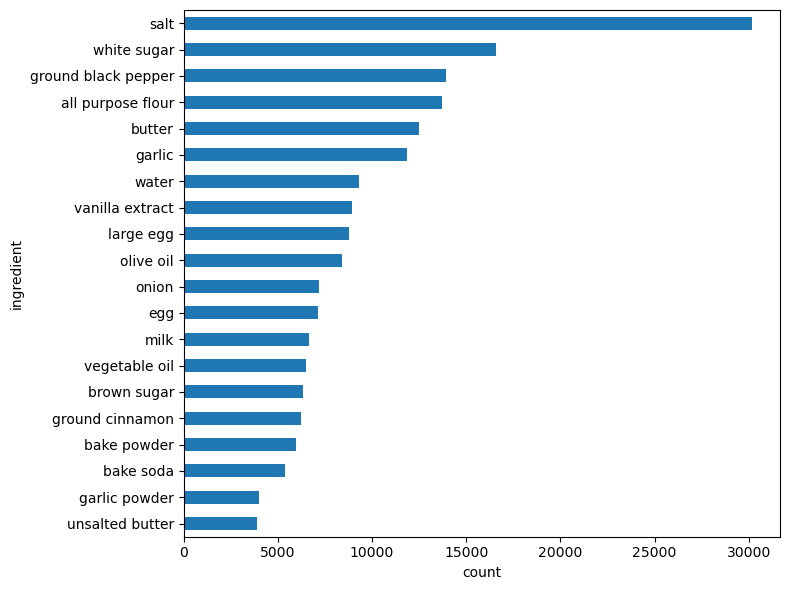

In [30]:
all_ingredients = [ing for recipe in df["ingredients_cleaned"] for ing in recipe]
ingredient_counts = Counter(all_ingredients)

top_ingredients = pd.DataFrame(ingredient_counts.most_common(20), columns=["ingredient", "count"])

print("Top 20 Most Common Ingredients : ")
plt.figure(figsize=(8, 5))
top_ingredients.plot(kind="barh", x="ingredient", y="count", figsize=(8,6), legend=False)
plt.gca().invert_yaxis()
plt.xlabel("count")
plt.tight_layout()
plt.savefig("visualizations/top20_common_ingredients.png", dpi=300, bbox_inches="tight")
plt.show()

Health Label Distribution Across Top Categories : 


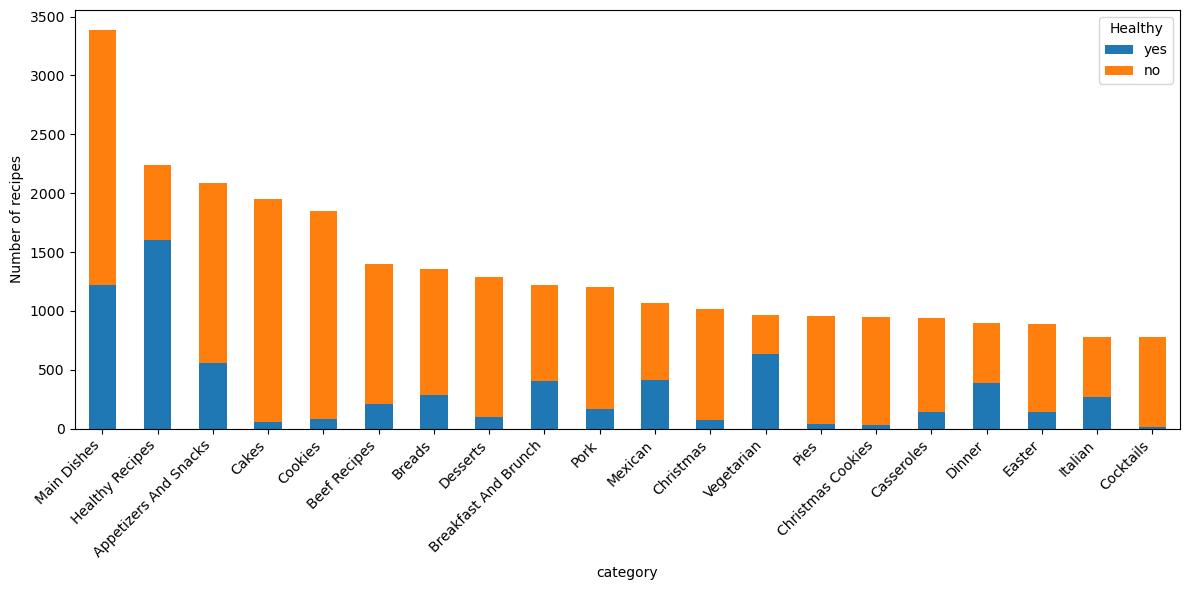

In [31]:
cat_health = df.groupby(["category", "Healthy"]).size().unstack(fill_value=0)

cat_health["total"] = cat_health.sum(axis=1)
cat_health = cat_health.sort_values("total", ascending=False).head(20)

print("Health Label Distribution Across Top Categories : ")
cat_health[["yes", "no"]].plot(kind="bar", stacked=True, figsize=(12,6))
plt.ylabel("Number of recipes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("visualizations/healthy_distrib_among_categ.png", dpi=300, bbox_inches="tight")
plt.show()

Most Frequent Ingredients in Healthy Recipes


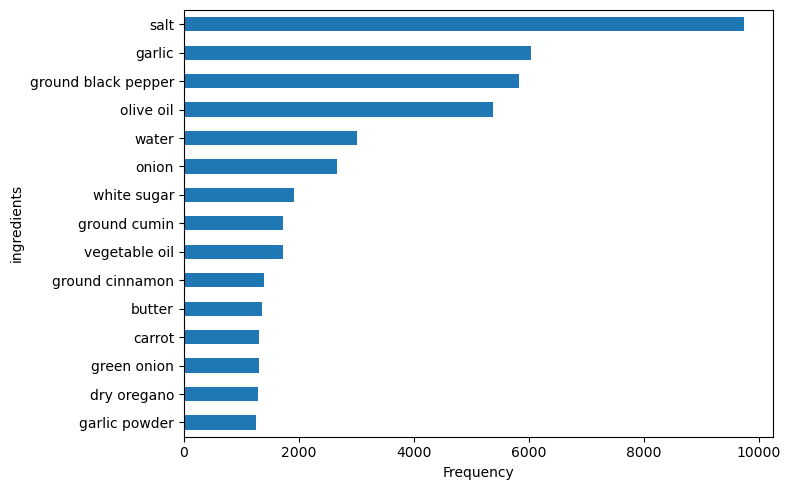

Most Frequent Ingredients in Unhealthy Recipes


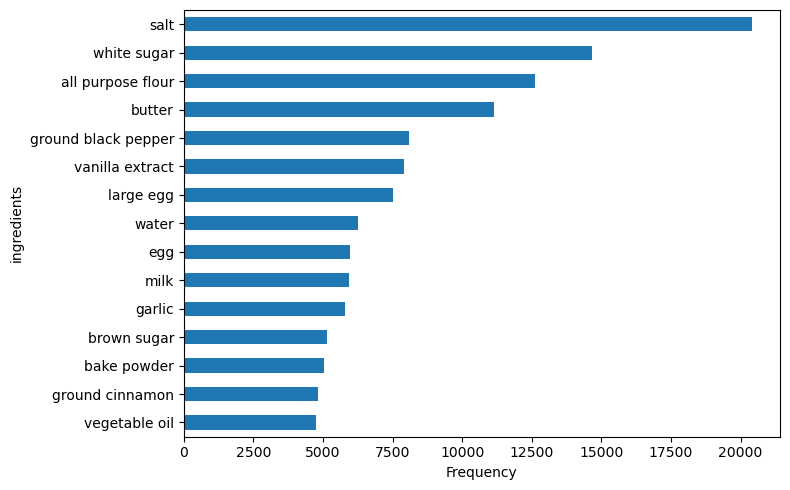

In [32]:
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

healthy_ings = [ing for recipe in df_healthy["ingredients_cleaned"] for ing in recipe]
unhealthy_ings = [ing for recipe in df_unhealthy["ingredients_cleaned"] for ing in recipe]

healthy_counts = Counter(healthy_ings)
unhealthy_counts = Counter(unhealthy_ings)

comp = pd.DataFrame({
    "healthy": pd.Series(healthy_counts),
    "unhealthy": pd.Series(unhealthy_counts)
}).fillna(0)

comp["total"] = comp["healthy"] + comp["unhealthy"]
comp = comp[comp["total"] >= 30]

comp["healthy_ratio"] = comp["healthy"] / comp["total"]
comp["unhealthy_ratio"] = comp["unhealthy"] / comp["total"]

top_healthy = comp.sort_values("healthy", ascending=False).head(15)
top_unhealthy = comp.sort_values("unhealthy", ascending=False).head(15)

print("Most Frequent Ingredients in Healthy Recipes")
plt.figure(figsize=(8, 5))
top_healthy["healthy"].sort_values().plot(kind="barh")
plt.xlabel("Frequency")
plt.ylabel("ingredients")
plt.tight_layout()
plt.savefig("visualizations/healthy_ingredients_frequency.png", dpi=300, bbox_inches="tight")
plt.show()

print("Most Frequent Ingredients in Unhealthy Recipes")
plt.figure(figsize=(8, 5))
top_unhealthy["unhealthy"].sort_values().plot(kind="barh")
plt.xlabel("Frequency")
plt.ylabel("ingredients")
plt.tight_layout()
plt.savefig("visualizations/unhealthy_ingredients_frequency.png", dpi=300, bbox_inches="tight")
plt.show()

Ingredients Most Associated with Healthy Recipes : 


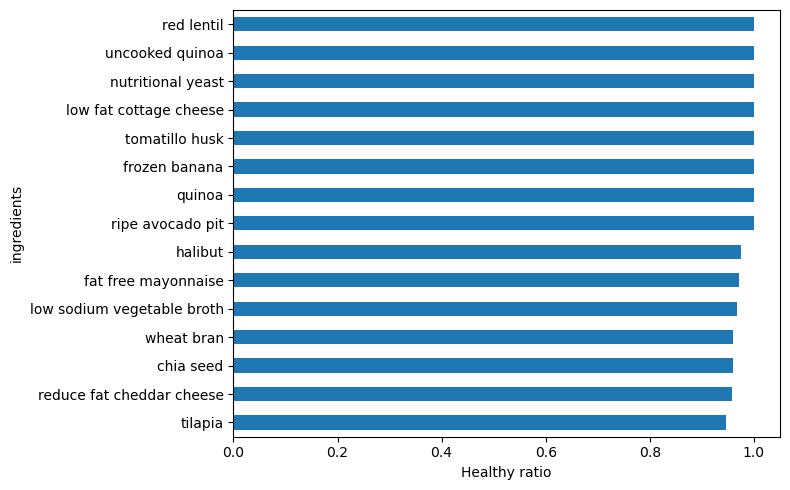

Ingredients Most Associated with Unhealthy Recipes : 


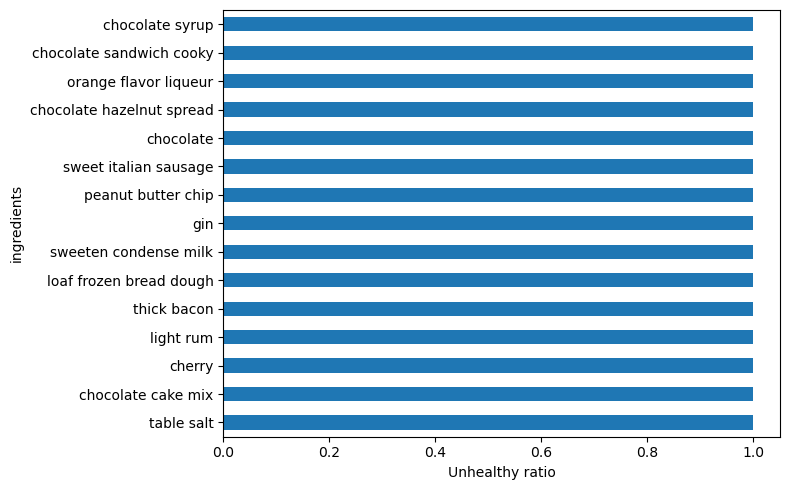

In [33]:
top_healthy = comp.sort_values("healthy_ratio", ascending=False).head(15)
top_unhealthy = comp.sort_values("unhealthy_ratio", ascending=False).head(15)

print("Ingredients Most Associated with Healthy Recipes : ")
plt.figure(figsize=(8, 5))
top_healthy["healthy_ratio"].sort_values().plot(kind="barh", figsize=(8,5))
plt.xlabel("Healthy ratio")
plt.ylabel("ingredients")
plt.tight_layout()
plt.savefig("visualizations/healthy_ingredients_ratio.png", dpi=300, bbox_inches="tight")
plt.show()

print("Ingredients Most Associated with Unhealthy Recipes : ")
plt.figure(figsize=(8, 5))
top_unhealthy["unhealthy_ratio"].sort_values().plot(kind="barh", figsize=(8,5))
plt.xlabel("Unhealthy ratio")
plt.ylabel("ingredients")
plt.tight_layout()
plt.savefig("visualizations/unhealthy_ingredients_ratio.png", dpi=300, bbox_inches="tight")
plt.show()